# **EMPLOYEE PERFORMANCE SCORE PREDICTION**

This project focuses on analysing employee data and building a machine learning model to **predict Employee Performance Score** based on workplace & employee-related factors.

## Exploratory Data Analysis

The dataset was explored using statistical analysis and visualisations to understand patterns in variables such as **Gender, Education Level, Age, Salary, Experience, Department, Overtime Hours, and Performance Score**.

A correlation analysis showed that **Monthly Salary had the strongest correlation with Performance Score (0.51)**, while most other numerical variables had very weak correlations.

## Data Preprocessing

Five features were selected for predicting Performance Score:

* **Years at Company**
* **Monthly Salary**
* **Overtime Hours**
* **Promotions**
* **Employee Satisfaction Score**

The data was split into **80% training and 20% testing sets**, and the features were standardised using `StandardScaler`.

## Machine Learning

Three classification models were explored:

1. **Logistic Regression**
2. **K-Nearest Neighbors (KNN)**
3. **Random Forest Classifier**
4. **Decision Tree Classifier**

Hyperparameter tuning was performed for KNN using `GridSearchCV`. The Decision Tree was configured with `criterion="entropy"` and `max_depth=12`.

## Model Evaluation

The Decision Tree achieved:

* **Training Accuracy:** 94.63%
* **Test Accuracy:** 94.11%
* **5-Fold Cross-Validation Accuracy:** 94.36%
* **Weighted F1-Score:** 0.94

The model showed similar training and test performance, indicating consistent results on unseen data.

## Streamlit Deployment

The trained Decision Tree and scaler were saved as **`model.pkl`** and **`scaler.pkl`**. A **Streamlit application** was then developed where users can enter the five selected employee attributes and receive a predicted Performance Score.

Overall, the project demonstrates a complete machine learning workflow, from **data analysis and preprocessing to model development, evaluation, and deployment through an interactive web application**.

In [42]:
# Importing required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split , GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
import joblib

In [43]:
# Loading the data into a dataframe from a .csv file

data = pd.read_csv("Extended_Employee_Performance_and_Productivity_Data.csv")
data.head()

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,1,IT,Male,55,Specialist,2022-01-19 08:03:05.556036,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,2,Finance,Male,29,Developer,2024-04-18 08:03:05.556036,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,3,Finance,Male,55,Specialist,2015-10-26 08:03:05.556036,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False
3,4,Customer Support,Female,48,Analyst,2016-10-22 08:03:05.556036,7,Bachelor,2,4800.0,52,10,28,12,100,10,0,1,1.86,False
4,5,Engineering,Female,36,Analyst,2021-07-23 08:03:05.556036,3,Bachelor,2,4800.0,38,11,29,13,100,15,9,1,1.25,False


In [44]:
# Checking Data types and null values

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Employee_ID                  100000 non-null  int64  
 1   Department                   100000 non-null  str    
 2   Gender                       100000 non-null  str    
 3   Age                          100000 non-null  int64  
 4   Job_Title                    100000 non-null  str    
 5   Hire_Date                    100000 non-null  str    
 6   Years_At_Company             100000 non-null  int64  
 7   Education_Level              100000 non-null  str    
 8   Performance_Score            100000 non-null  int64  
 9   Monthly_Salary               100000 non-null  float64
 10  Work_Hours_Per_Week          100000 non-null  int64  
 11  Projects_Handled             100000 non-null  int64  
 12  Overtime_Hours               100000 non-null  int64  
 13  Sick_Days  

In [45]:
# Statistical summary of the data

data.describe()

,Employee_ID,Age,Years_At_Company,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,41.029410,4.476070,2.995430,6403.211000,44.956950,24.431170,14.514930,7.008550,50.090500,10.013560,49.506060,0.999720,2.999088
std,28867.657797,11.244121,2.869336,1.414726,1372.508717,8.942003,14.469584,8.664026,4.331591,35.351157,5.495405,28.890383,0.815872,1.150719
min,1.000000,22.000000,0.000000,1.000000,3850.000000,30.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
25%,25000.750000,31.000000,2.000000,2.000000,5250.000000,37.000000,12.000000,7.000000,3.000000,25.000000,5.000000,25.000000,0.000000,2.010000
50%,50000.500000,41.000000,4.000000,3.000000,6500.000000,45.000000,24.000000,15.000000,7.000000,50.000000,10.000000,49.000000,1.000000,3.000000
75%,75000.250000,51.000000,7.000000,4.000000,7500.000000,53.000000,37.000000,22.000000,11.000000,75.000000,15.000000,75.000000,2.000000,3.990000
max,100000.000000,60.000000,10.000000,5.000000,9000.000000,60.000000,49.000000,29.000000,14.000000,100.000000,19.000000,99.000000,2.000000,5.000000


In [46]:
# Checking for duplicates, no duplicates found

data.duplicated().sum()

np.int64(0)

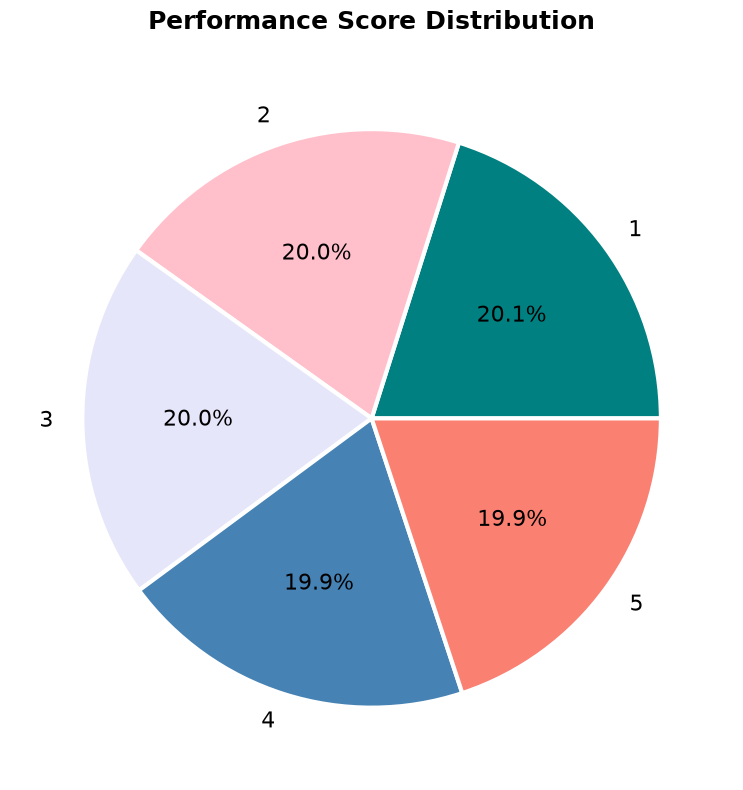

In [47]:
# Visualising the distribution of Performance Score

plt.figure(figsize=(8, 8))
data["Performance_Score"].value_counts().plot(kind="pie",autopct="%1.1f%%",colors=["teal", "pink", "lavender", "steelblue","salmon"],wedgeprops={"edgecolor": "white", "linewidth": 3},textprops={"fontsize": 16})
plt.title("Performance Score Distribution",fontsize=18,fontweight="bold",pad=20)
plt.ylabel("")
plt.tight_layout()
plt.show()

The **Performance Score** distribution is highly balanced, with each score representing approximately **20% of the dataset**. Score 1 has the highest number of observations (20,120), while Score 5 has the lowest (19,928). Overall, there is very little variation in the number of employees across the five performance-score categories.

In [48]:
data.columns

Index(['Employee_ID', 'Department', 'Gender', 'Age', 'Job_Title', 'Hire_Date',
       'Years_At_Company', 'Education_Level', 'Performance_Score',
       'Monthly_Salary', 'Work_Hours_Per_Week', 'Projects_Handled',
       'Overtime_Hours', 'Sick_Days', 'Remote_Work_Frequency', 'Team_Size',
       'Training_Hours', 'Promotions', 'Employee_Satisfaction_Score',
       'Resigned'],
      dtype='str')

In [49]:
data.sample(10)

,Employee_ID,Department,Gender,Age,Job_Title,Hire_Date,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
96361,96362,IT,Female,40,Technician,2024-07-07 08:03:05.556036,0,Master,5,5250.0,42,26,13,9,100,4,72,0,3.10,True
64035,64036,HR,Male,28,Developer,2019-03-15 08:03:05.556036,5,Master,1,5500.0,50,43,18,13,75,8,25,1,3.40,False
10261,10262,Marketing,Male,26,Technician,2018-06-16 08:03:05.556036,6,Bachelor,5,5250.0,41,34,2,13,50,12,69,2,4.78,False
59833,59834,Operations,Male,26,Engineer,2021-05-20 08:03:05.556036,3,Bachelor,5,9000.0,33,2,28,7,0,4,50,0,2.89,False
58458,58459,Operations,Female,56,Developer,2020-01-10 08:03:05.556036,4,Bachelor,1,5500.0,47,32,8,10,25,8,43,0,1.03,False
63251,63252,Operations,Male,58,Specialist,2017-10-08 08:03:05.556036,6,Bachelor,4,6300.0,39,19,26,6,75,16,73,2,3.07,False
35400,35401,Finance,Other,24,Developer,2019-11-22 08:03:05.556036,4,High School,3,6500.0,46,42,26,8,50,15,99,1,1.36,False
3295,3296,Marketing,Female,28,Consultant,2019-01-01 08:03:05.556036,5,Bachelor,3,7150.0,37,46,27,6,50,1,81,0,4.19,False
73261,73262,IT,Other,23,Consultant,2023-10-21 08:03:05.556036,0,High School,5,8250.0,53,39,12,12,100,6,38,1,2.61,False
90685,90686,Marketing,Female,53,Technician,2018-02-09 08:03:05.556036,6,Bachelor,4,4900.0,57,8,2,8,0,5,37,1,4.49,False


In [50]:
# Dropping redundant columns

data = data.drop(["Employee_ID","Hire_Date"], axis = 1)
data.head(3)

,Department,Gender,Age,Job_Title,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
0,IT,Male,55,Specialist,2,High School,5,6750.0,33,32,22,2,0,14,66,0,2.63,False
1,Finance,Male,29,Developer,0,High School,5,7500.0,34,34,13,14,100,12,61,2,1.72,False
2,Finance,Male,55,Specialist,8,High School,3,5850.0,37,27,6,3,50,10,1,0,3.17,False


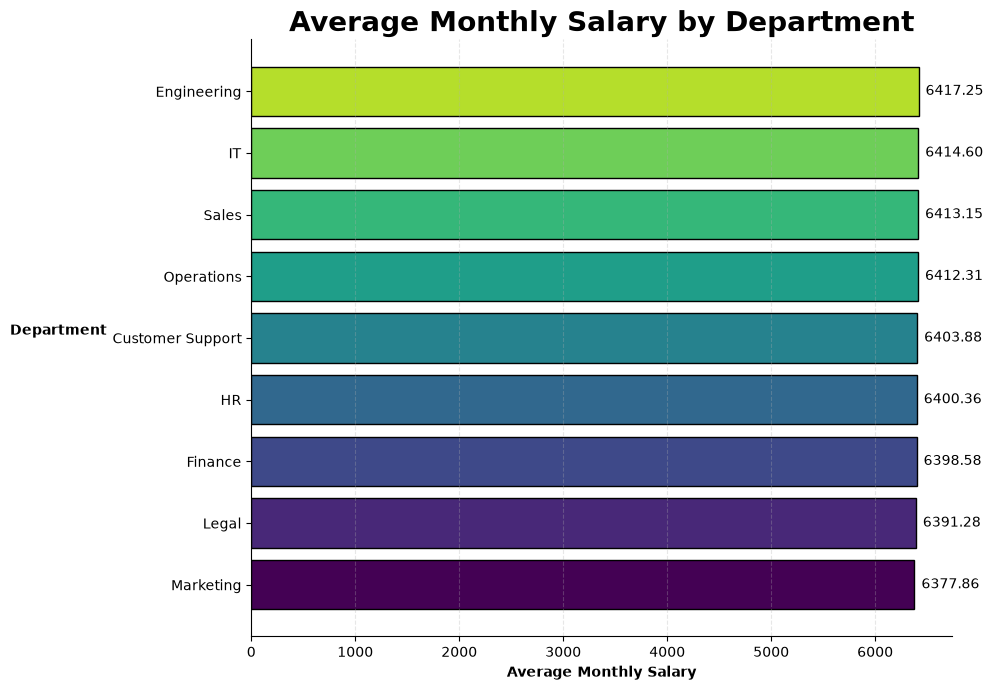

In [51]:
# Calculating and visualising average monthly salary by department

avg_salary_dept = (data.groupby("Department")["Monthly_Salary"].mean().sort_values(ascending=True))
plt.figure(figsize=(10, 7))
colors = [plt.cm.viridis(i / len(avg_salary_dept)) for i in range(len(avg_salary_dept))]
bars = plt.barh(avg_salary_dept.index,avg_salary_dept.values,color=colors,edgecolor="black")
plt.title("Average Monthly Salary by Department",fontsize=20,fontweight="bold")
plt.xlabel("Average Monthly Salary", fontweight="bold")
plt.ylabel("Department", fontweight="bold",rotation=0, ha="right")
plt.bar_label(bars, fmt="%.2f", padding=5)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## Average Monthly Salary Across Departments
- The average monthly salaries are very similar across all departments, ranging from approximately **6,378-6,417 Dollars**.  
- **Engineering** has the highest average monthly salary at **6,417.25 Dollars**, followed closely by **IT and Sales**.   
- **Marketing** has the lowest average at **6,377.86 Dollars**.   
- Overall, the difference between the highest and lowest departmental averages is relatively small, suggesting limited variation in average monthly salary across departments.

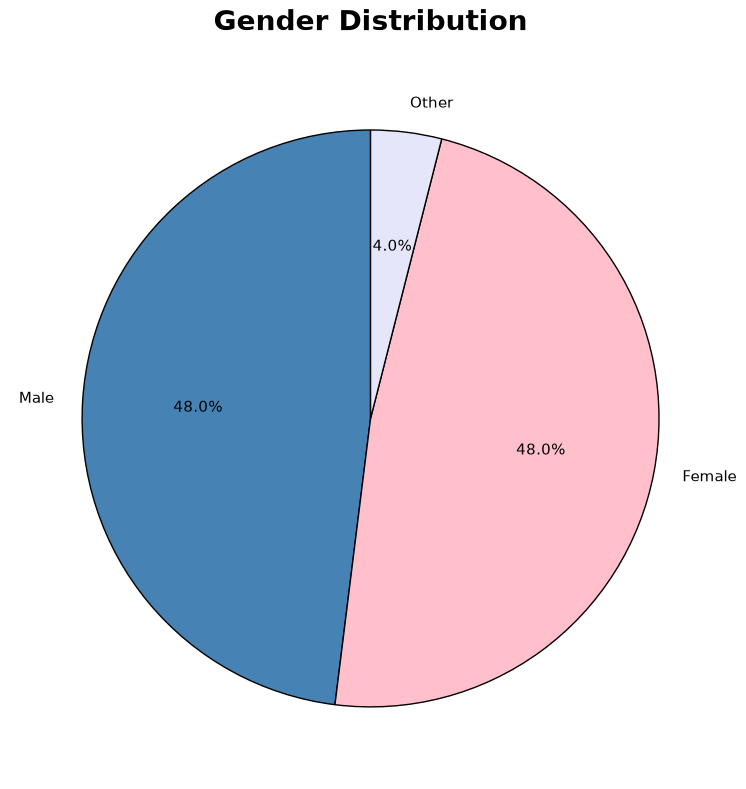

In [52]:
# Calculating and visualising the distribution of employees by gender

gender_counts = data["Gender"].value_counts()
plt.figure(figsize=(8, 8))
gender_counts.plot(kind="pie",autopct="%1.1f%%",startangle=90,colors=["steelblue", "pink", "lavender"],wedgeprops={"edgecolor": "black"},textprops={"fontsize": 11})
plt.title("Gender Distribution", fontsize=20, fontweight="bold", pad=20)
plt.ylabel("")
plt.tight_layout()
plt.show()

## Gender Distribution of Employees
The gender distribution is fairly balanced between male and female employees, with **48,031 males** and **48,001 females**. Employees identifying as Other account for **3,968 (3.9%)** of the dataset, representing a much smaller proportion.

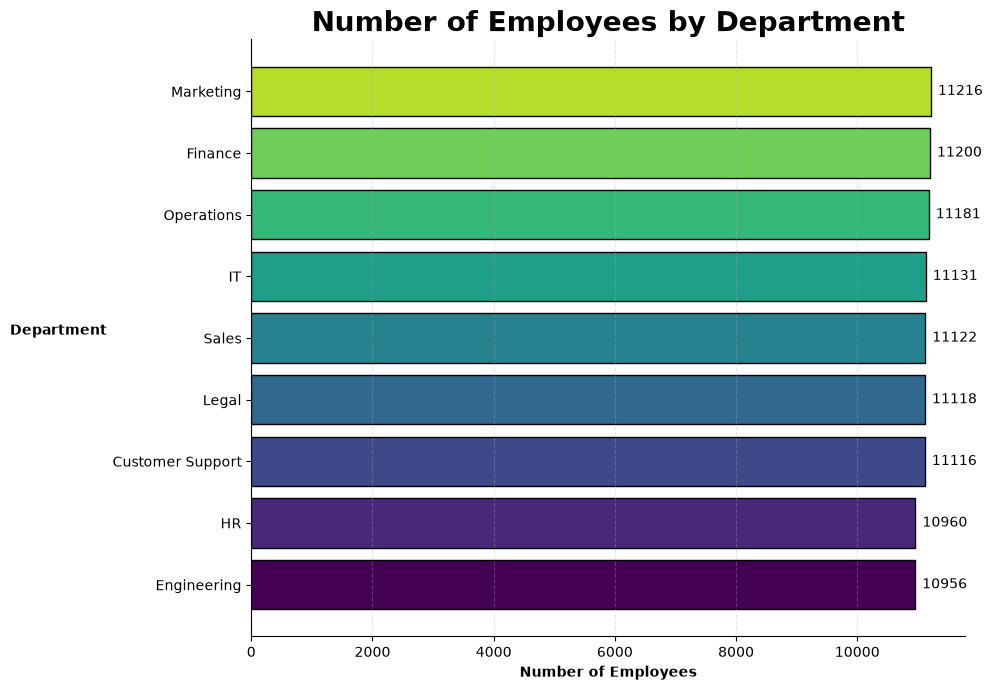

In [53]:
# Calculating and visualising the number of employees in each department

department_counts = data["Department"].value_counts().sort_values(ascending=True)
plt.figure(figsize=(10, 7))
colors = [plt.cm.viridis(i / len(department_counts)) for i in range(len(department_counts))]
bars = plt.barh(department_counts.index,department_counts.values,color=colors,edgecolor="black")
plt.title("Number of Employees by Department", fontsize=20, fontweight="bold")
plt.xlabel("Number of Employees", fontweight="bold")
plt.ylabel("Department", fontweight="bold", rotation=0, ha="right")
plt.bar_label(bars, fmt="%.0f", padding=5)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## Employee Ditribution across Departments
Employee distribution is fairly **balanced across departments**, with each department having roughly **11,000 employees**. Marketing has the highest number of employees (11,216), while Engineering has the lowest (10,956). The difference between the two is only 260 employees, indicating very little variation in department size.

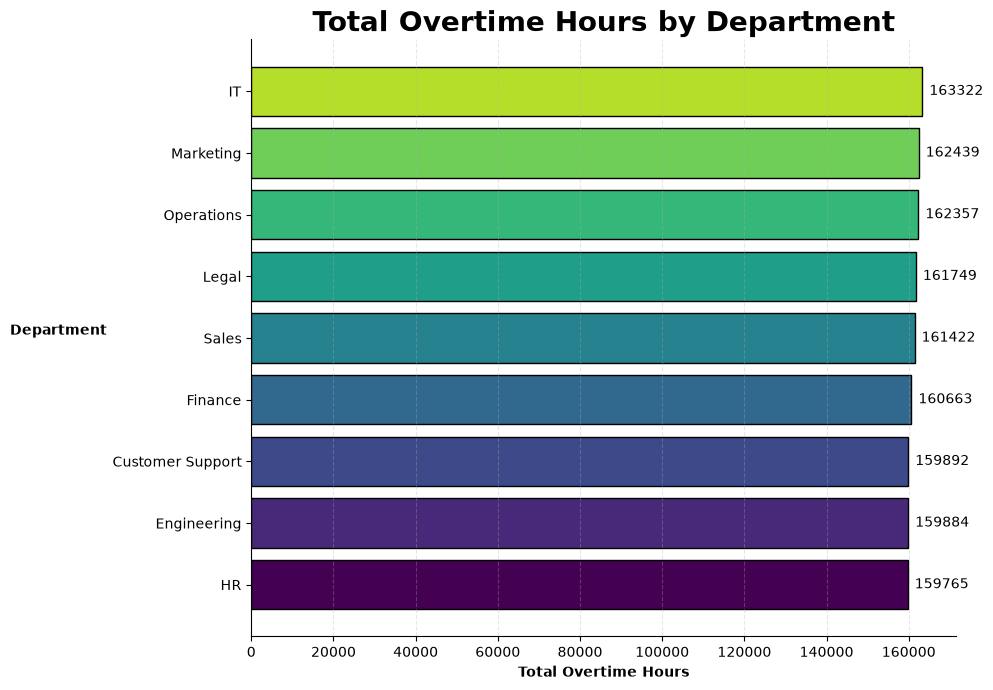

In [54]:
# Calculating and visualising total overtime hours by department

overtime_dept = (data.groupby("Department")["Overtime_Hours"].sum().sort_values(ascending=True))
plt.figure(figsize=(10, 7))
colors = [plt.cm.viridis(i / len(overtime_dept)) for i in range(len(overtime_dept))]
bars = plt.barh(overtime_dept.index,overtime_dept.values,color=colors,edgecolor="black")
plt.title("Total Overtime Hours by Department", fontsize=20, fontweight="bold")
plt.xlabel("Total Overtime Hours", fontweight="bold")
plt.ylabel("Department", fontweight="bold", rotation=0, ha="right")
plt.bar_label(bars, fmt="%.0f", padding=5)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

* **IT** records the highest total overtime hours at **163,322 hours**.
* **Marketing** and **Operations** follow with **162,439** and **162,357 hours**, respectively.
* **HR** has the lowest total overtime at **159,765 hours**.
* Overall, the differences are relatively small, with only **3,557 hours** separating the highest and lowest departments.

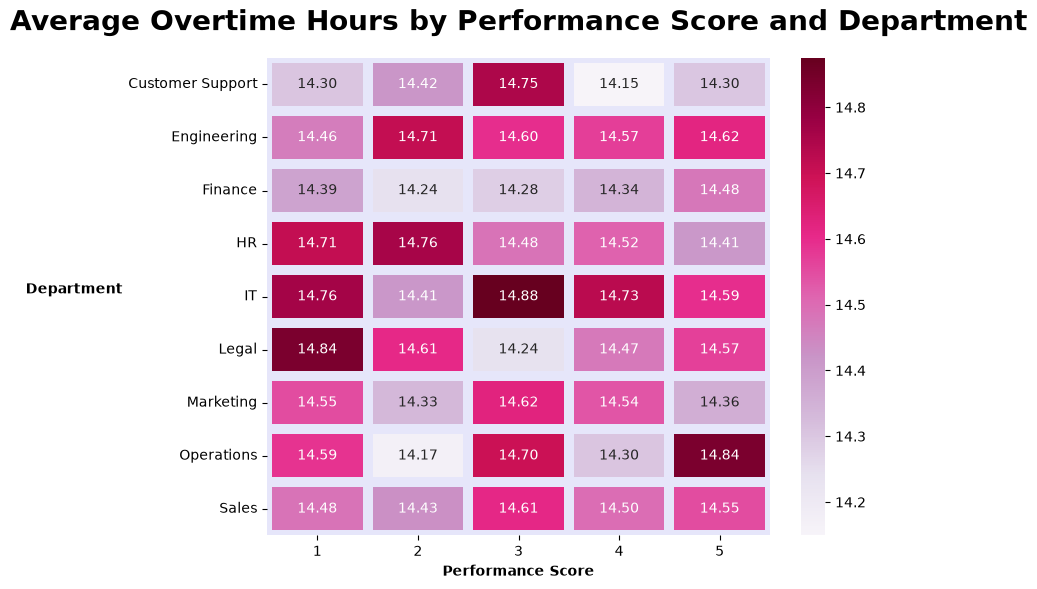

In [55]:
# Calculating and visualising average overtime hours by performance score and department

avg_overtime = data.pivot_table(index="Department",columns="Performance_Score",values="Overtime_Hours",aggfunc="mean")
plt.figure(figsize=(9, 6))
sns.heatmap(avg_overtime,annot=True,fmt=".2f",cmap="PuRd",linewidths=7,linecolor="lavender")
plt.title("Average Overtime Hours by Performance Score and Department",fontsize=20,fontweight="bold",pad=20)
plt.xlabel("Performance Score", fontweight="bold")
plt.ylabel("Department", fontweight="bold", rotation=0, ha="right")
plt.tight_layout()
plt.show()

## Relationship Between Overtime Hours, Performance Score and Department
The average overtime hours are very similar across all performance scores and departments, with **most values falling between approximately 14.2 and 14.9 hours**. There is no clear pattern showing that higher performance scores consistently correspond to higher or lower overtime hours. For example, IT has the highest average at 14.88 hours for Performance Score 3, while Operations reaches 14.84 hours for Score 5. Overall, overtime hours appear relatively consistent across the different performance-score categories.

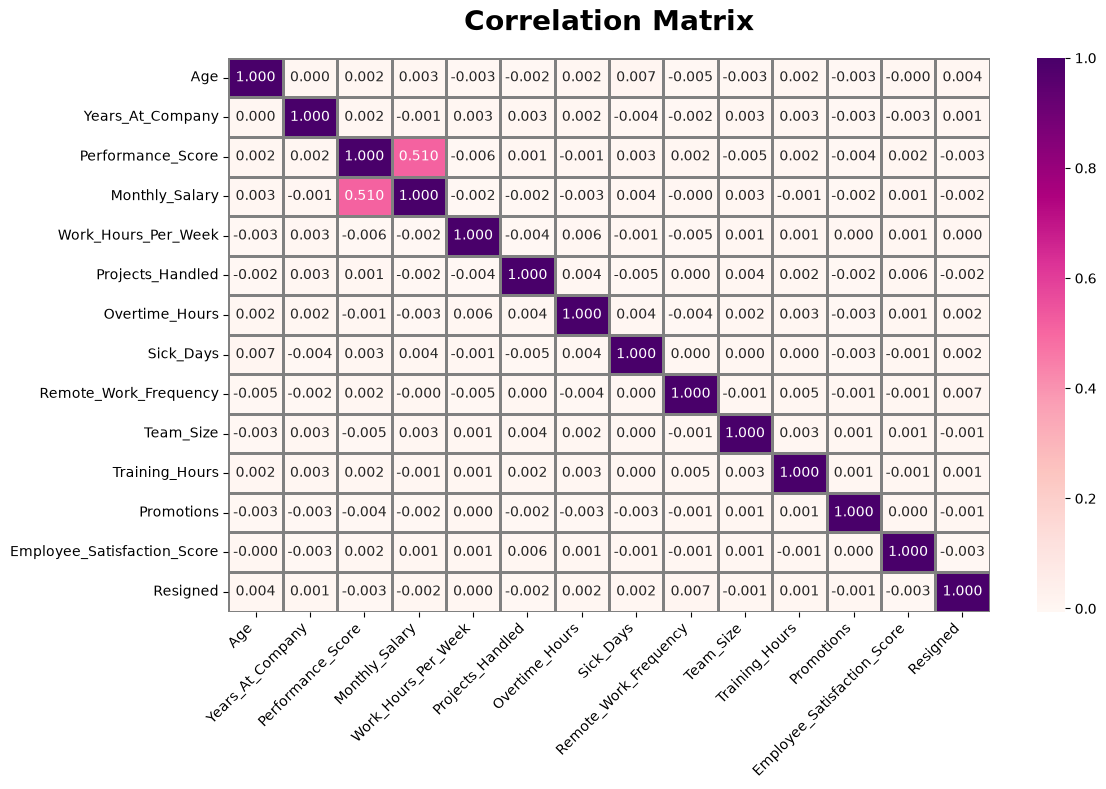

In [56]:
# Calculating and visualising the correlation matrix

correlation_matrix = data.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix,annot=True,fmt=".3f",cmap="RdPu",linewidths=2,linecolor="grey")
plt.title("Correlation Matrix", fontsize=20, fontweight="bold", pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Correlation with Performance Score

The correlation analysis shows that **Monthly Salary has the strongest relationship with Performance Score**, with a moderate positive correlation of **0.51**. This indicates that higher performance scores are associated with higher monthly salaries in the dataset.

The remaining variables show **very weak or negligible correlations** with Performance Score, with correlation values close to zero. Variables such as Sick Days, Training Hours, Remote Work Frequency, Employee Satisfaction, Age, and Years at Company show almost no linear relationship with performance score.

Interestingly, **Overtime Hours** has a very small negative correlation (**-0.0013**), suggesting virtually no linear relationship between overtime and performance score. Overall, **Monthly Salary stands out as the only variable with a meaningful correlation with Performance Score** in this dataset.

In [57]:
# To view 10 random rows from the dataframe

data.sample(10)

,Department,Gender,Age,Job_Title,Years_At_Company,Education_Level,Performance_Score,Monthly_Salary,Work_Hours_Per_Week,Projects_Handled,Overtime_Hours,Sick_Days,Remote_Work_Frequency,Team_Size,Training_Hours,Promotions,Employee_Satisfaction_Score,Resigned
52755,Sales,Female,53,Specialist,1,High School,1,4950.0,39,2,11,12,25,18,15,2,2.14,False
36083,Customer Support,Female,40,Engineer,5,Bachelor,5,9000.0,37,37,10,4,100,14,7,0,2.26,False
21185,Legal,Male,60,Manager,1,High School,2,7200.0,34,16,6,6,100,8,90,0,4.33,False
92496,Operations,Female,53,Consultant,3,Bachelor,1,6050.0,52,39,21,4,50,9,99,2,2.80,False
82327,HR,Male,23,Developer,7,High School,4,7000.0,35,2,20,3,0,5,64,2,1.94,False
25855,Sales,Male,33,Specialist,7,Master,3,5850.0,38,31,29,10,100,5,78,1,4.15,True
3734,HR,Male,52,Developer,6,High School,1,5500.0,47,4,20,13,50,13,19,0,3.66,True
3260,Finance,Female,26,Consultant,3,Bachelor,1,6050.0,34,6,3,4,25,9,76,2,3.09,False
26324,Operations,Female,25,Analyst,6,Master,2,4800.0,38,29,9,6,50,12,31,1,1.32,False
21045,Marketing,Female,56,Engineer,2,High School,5,9000.0,34,46,6,2,0,18,56,0,3.51,False


In [58]:
# Checking all the column names in the dataframe

data.columns

Index(['Department', 'Gender', 'Age', 'Job_Title', 'Years_At_Company',
       'Education_Level', 'Performance_Score', 'Monthly_Salary',
       'Work_Hours_Per_Week', 'Projects_Handled', 'Overtime_Hours',
       'Sick_Days', 'Remote_Work_Frequency', 'Team_Size', 'Training_Hours',
       'Promotions', 'Employee_Satisfaction_Score', 'Resigned'],
      dtype='str')

In [59]:
# Selecting features and target variable
#Splitting the data into training and testing sets (80% and 20% respectively)

X = data[['Years_At_Company','Monthly_Salary', 'Overtime_Hours','Promotions', 'Employee_Satisfaction_Score']]
y = data["Performance_Score"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state=42)

In [60]:
# Standardising the features so they have a mean of 0 and a standard deviation of 1
# Fitting the scaler on the training data and transforming it
# Transforming the test data using the same scaler fitted on the training data

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   #Scaled X_train
X_test_scaled = scaler.transform(X_test)         #Scaled X_test

In [62]:
# LOGISTIC REGRESSION

log_model = LogisticRegression(max_iter = 1000)
log_model.fit(X_train_scaled,y_train)
log_pred = log_model.predict(X_test_scaled)
print("Accuracy score on model is:", accuracy_score(y_test, log_pred))
print("\nClassification Report:")
print(classification_report(y_test, log_pred))

Accuracy score on model is: 0.3114

Classification Report:
              precision    recall  f1-score   support

           1       0.34      0.57      0.43      4024
           2       0.23      0.13      0.17      4003
           3       0.23      0.15      0.18      4000
           4       0.26      0.14      0.18      3988
           5       0.36      0.56      0.44      3985

    accuracy                           0.31     20000
   macro avg       0.28      0.31      0.28     20000
weighted avg       0.28      0.31      0.28     20000



In [64]:
# K-NEAREST NEIGHBORS CLASSIFIER
# Finding the best combination of hyperparameters using 5 Fold Cross Validation

kn = KNeighborsClassifier()
param_grid = {"n_neighbors": [3,5,8,10],
              "weights": ["uniform","distance"]}
gridkn = GridSearchCV(kn, param_grid, cv = 5)
gridkn.fit(X_train_scaled, y_train)
print("Best Parameters:", gridkn.best_params_)
print("Best CV Accuracy:", gridkn.best_score_)
kn_pred = gridkn.predict(X_test_scaled)
print("Accuracy on model is:", accuracy_score(y_test,kn_pred))
print("\nClassification Report:")
print(classification_report(y_test, kn_pred))

Best Parameters: {'n_neighbors': 3, 'weights': 'distance'}
Best CV Accuracy: 0.47628750000000003
Accuracy on model is: 0.4986

Classification Report:
              precision    recall  f1-score   support

           1       0.44      0.50      0.47      4024
           2       0.41      0.46      0.43      4003
           3       0.49      0.48      0.49      4000
           4       0.55      0.52      0.53      3988
           5       0.63      0.54      0.59      3985

    accuracy                           0.50     20000
   macro avg       0.51      0.50      0.50     20000
weighted avg       0.51      0.50      0.50     20000



In [65]:
# RANDOM FOREST CLASSIFIER

rf = RandomForestClassifier(
    n_estimators=300,
    criterion="entropy",
    max_depth=15,
    random_state=42)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.8302
              precision    recall  f1-score   support

           1       0.58      0.99      0.73      4024
           2       0.92      0.62      0.74      4003
           3       0.93      0.92      0.93      4000
           4       1.00      0.86      0.92      3988
           5       0.99      0.75      0.86      3985

    accuracy                           0.83     20000
   macro avg       0.88      0.83      0.84     20000
weighted avg       0.88      0.83      0.84     20000



In [40]:
# DECISION TREE CLASSIFIER

tree = DecisionTreeClassifier(criterion="entropy",max_depth = 12, random_state=42)
tree.fit(X_train, y_train)
pred = tree.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9411


In [41]:
# Decision Tree Model Evaluation

cv_scores = cross_val_score(tree,X_train,y_train,cv=5, scoring="accuracy")
print("-Cross Validation Scores:", cv_scores)
print("-Mean Cross Validation Score:", np.mean(cv_scores))

train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)
print("-Training Accuracy:", accuracy_score(y_train, train_pred))
print("-Test Accuracy:", accuracy_score(y_test, test_pred))
print(classification_report(y_test, pred))

-Cross Validation Scores: [0.94675   0.942375  0.943     0.943875  0.9421875]
-Mean Cross Validation Score: 0.9436375
-Training Accuracy: 0.94625
-Test Accuracy: 0.9411
              precision    recall  f1-score   support

           1       0.87      0.99      0.93      3977
           2       0.92      0.78      0.84      4054
           3       1.00      1.00      1.00      4097
           4       1.00      1.00      1.00      3968
           5       0.92      0.94      0.93      3904

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000



In [25]:
tree.classes_

array([1, 2, 3, 4, 5])

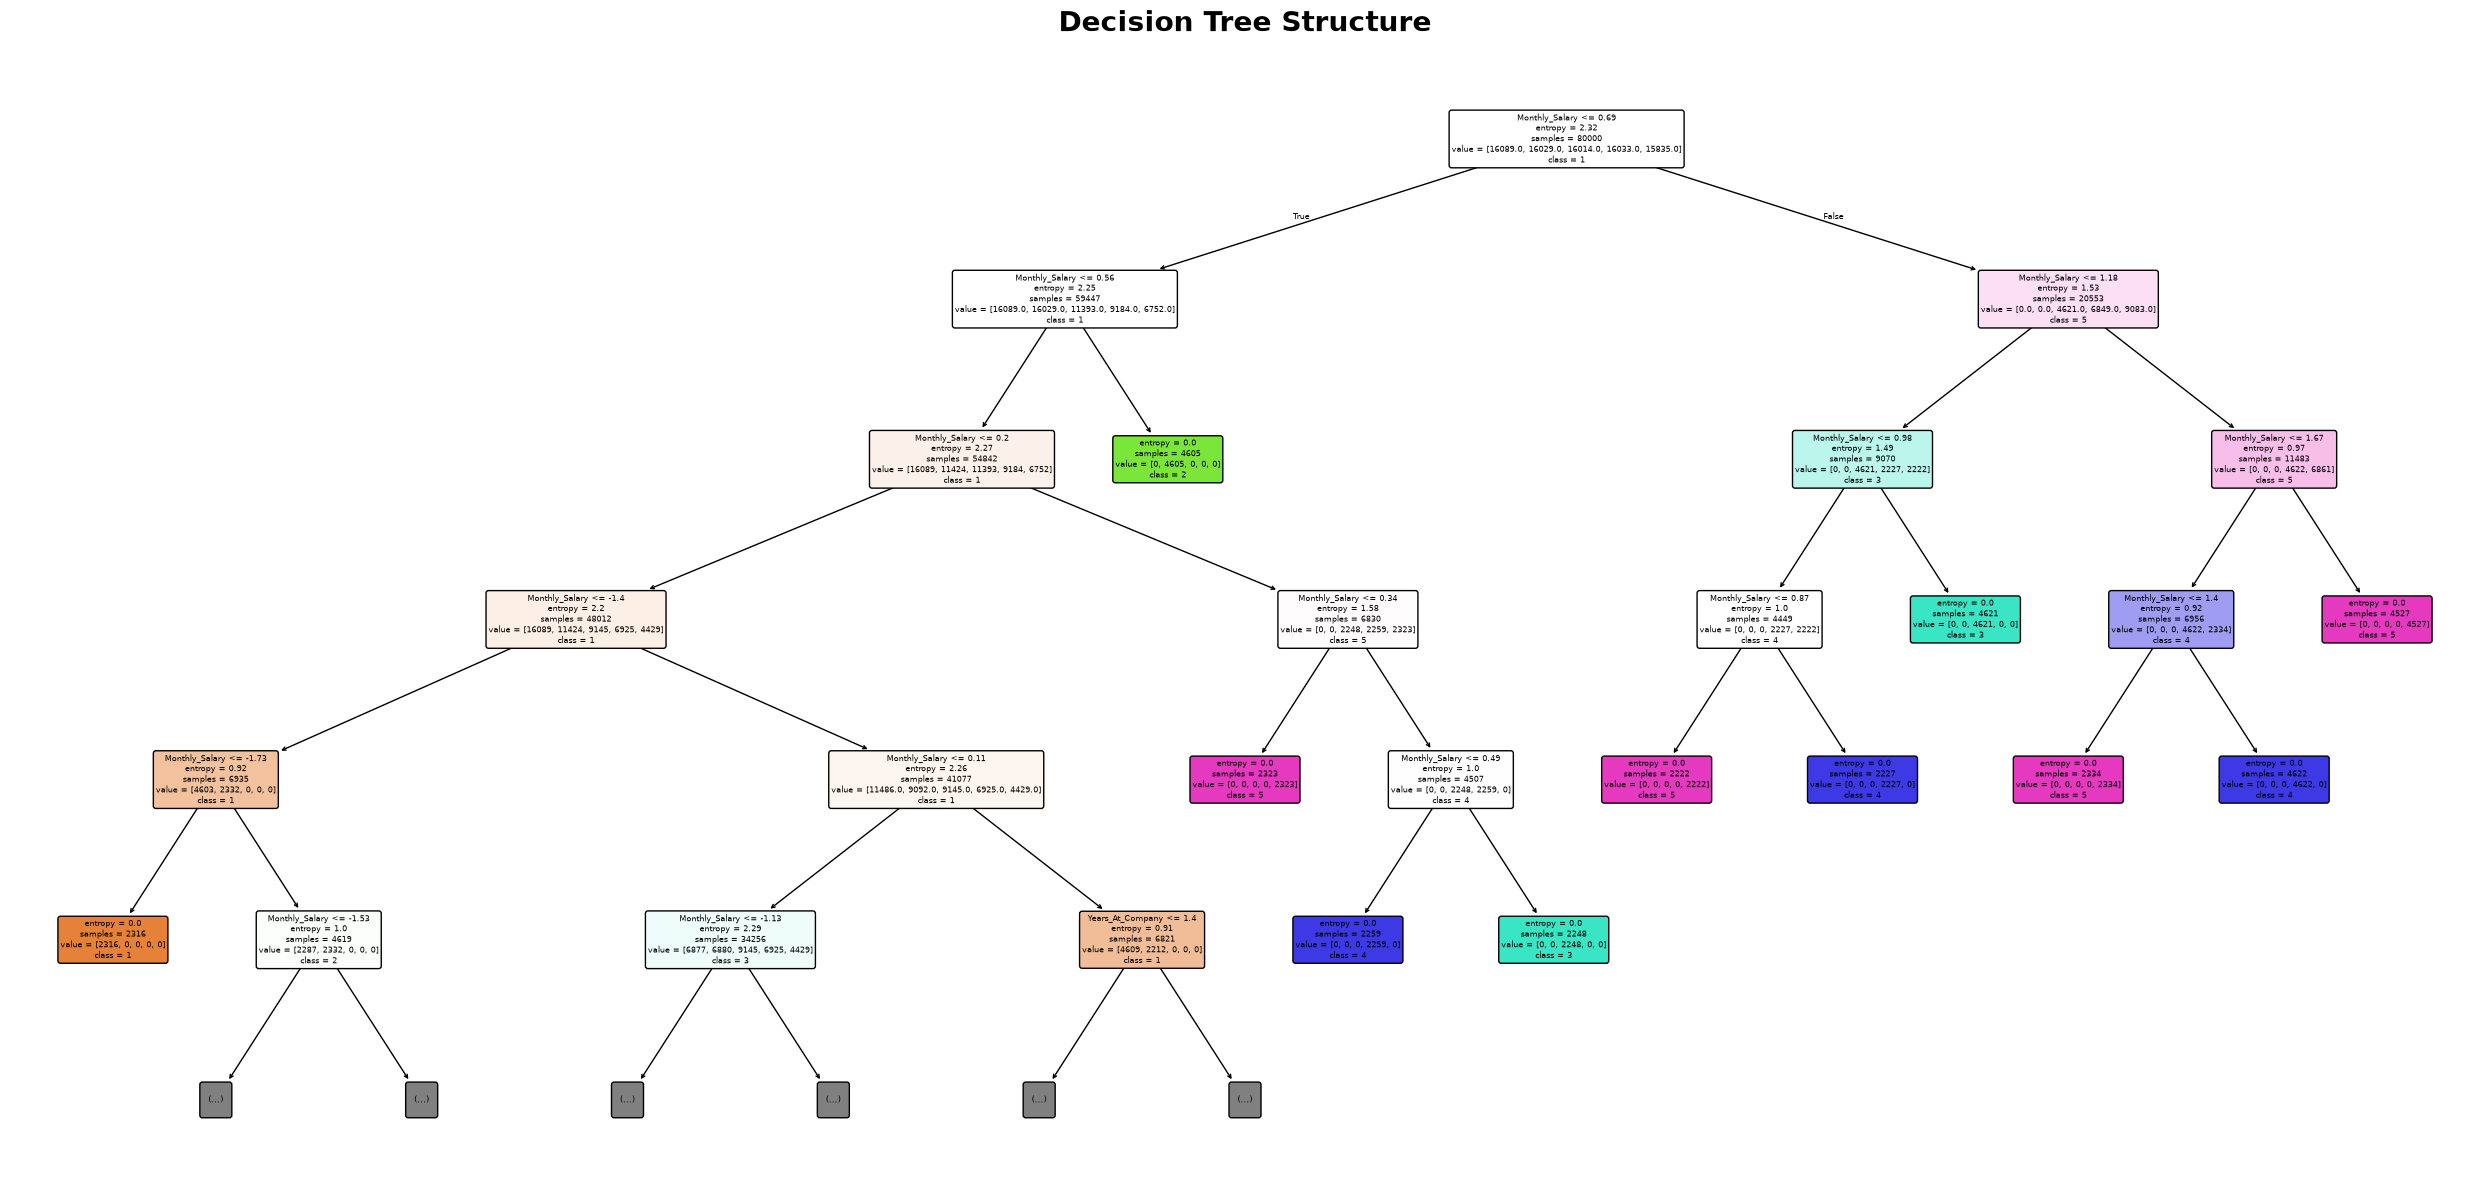

In [26]:
# Visualising the Decision Tree

plt.figure(figsize=(25, 12))
_ = plot_tree(
    tree,
    max_depth=5,              # Limit depth for a clearer visualisation
    feature_names=X.columns,
    class_names=("1", "2", "3", "4", "5"),
    filled=True,
    rounded=True,
    precision=2,
    fontsize=6)
plt.title("Decision Tree Structure", fontsize=20, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

## **Conclusion**

The Decision Tree Classifier achieved a **test accuracy of 94.11%**, with a mean **5-fold cross-validation accuracy of 94.36%**. The training accuracy of **94.63%** is close to the test accuracy, indicating consistent performance with no significant gap between training and unseen data.

The classification report shows a **macro-average and weighted-average F1-score of 0.94**, indicating strong overall classification performance across the five Performance Score categories. The model performed particularly well for **Scores 3 and 4**, achieving an **F1-score of 1.00** for both, while **Score 2** had the lowest **F1-score of 0.84**, mainly due to its lower recall of **0.78**.

Overall, the model demonstrates **strong and consistent performance** in predicting Performance Score, with good generalization between the training and test datasets.

In [73]:
# Decision Tree Feature Importance Table

feature_importance_df = pd.DataFrame({"Feature": X.columns,"Importance": tree.feature_importances_})
feature_importance_df["Importance (%)"] = (feature_importance_df["Importance"] * 100)
feature_importance_df = feature_importance_df.sort_values(by="Importance",ascending=False).reset_index(drop=True)
feature_importance_df

,Feature,Importance,Importance (%)
0,Monthly_Salary,0.998554,99.855388
1,Overtime_Hours,0.000524,0.052419
2,Employee_Satisfaction_Score,0.000498,0.049773
3,Years_At_Company,0.000264,0.026388
4,Promotions,0.000160,0.016032


In [74]:
# Saving the fitted scaler for future predictions

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [75]:
# Saving the trained Decision Tree model for future predictions

joblib.dump(tree, "model.pkl")

['model.pkl']